In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

1. Load the dataset and print the number of rows, columns, and data types of each column.

In [2]:
df = pd.read_csv('AB_NYC_2019.csv')
df.shape

(48895, 16)

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

2. Find how many missing values exist in each column, and what percentage of reviews_per_month is missing.

In [5]:
missing = (df['reviews_per_month'].isnull().sum() / len(df)) * 100
missing

np.float64(20.55833929849678)

3. Get the count of listings per neighbourhood_group.

In [6]:
(df['neighbourhood_group'].value_counts(normalize=True) * 100).round(2)

neighbourhood_group
Manhattan        44.30
Brooklyn         41.12
Queens           11.59
Bronx             2.23
Staten Island     0.76
Name: proportion, dtype: float64

4. Find the top 10 neighbourhoods with the most listings.

In [7]:
top10 = df['neighbourhood'].value_counts().sort_values(ascending=False).head(10)
top10

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64

5. Find the average price per room_type.

In [8]:
avg_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False).round()
avg_room

room_type
Entire home/apt    212.0
Private room        90.0
Shared room         70.0
Name: price, dtype: float64

6. Plot a histogram of price (hint: you'll need to handle outliers — (try filtering price < 500 for a readable plot).

Text(0.5, 1.0, 'histogram of price')

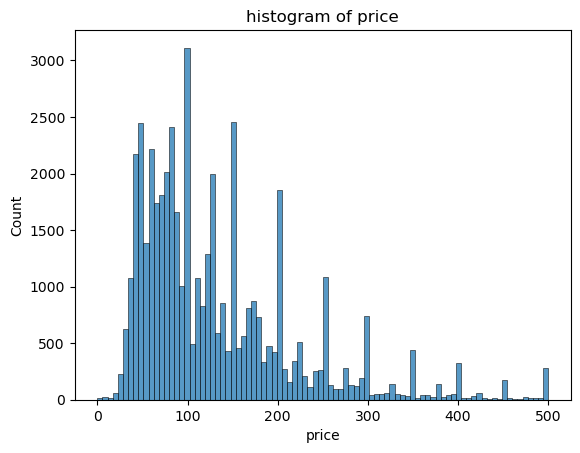

In [9]:
df_price = df[(df['price'] >= 0) & (df['price'] <=500)]
sns.histplot( df_price['price'],palette='crest')
plt.title('histogram of price')

7. Plot a bar chart showing the number of listings per neighbourhood_group.

Text(0.5, 1.0, 'Number of listings per neighbourhood group')

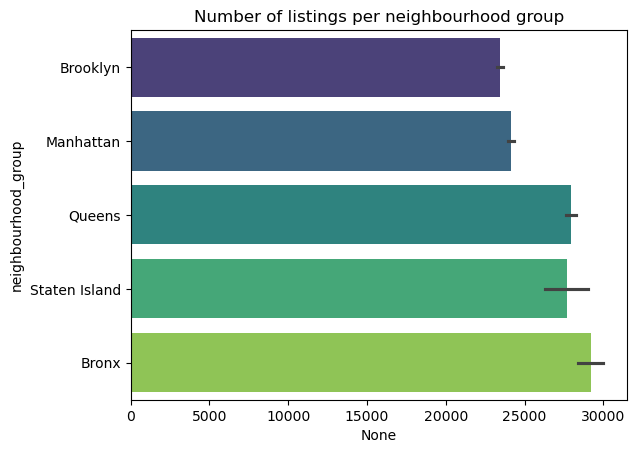

In [10]:
sns.barplot(x= df['calculated_host_listings_count'].index,y= 'neighbourhood_group',data=df,palette='viridis')
plt.title('Number of listings per neighbourhood group')

8. Plot a horizontal bar chart of the top 10 neighbourhoods by listing count.

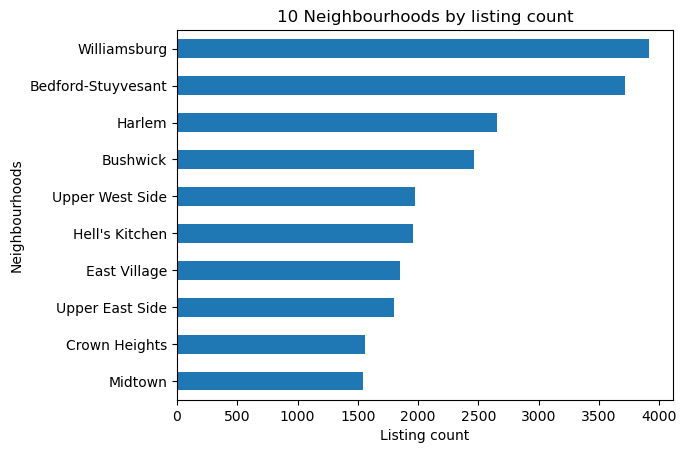

In [11]:
top10 = df['neighbourhood'].value_counts().sort_values(ascending=False).head(10)
top10.plot(kind = 'barh')
plt.title('10 Neighbourhoods by listing count')
plt.xlabel('Listing count')
plt.ylabel('Neighbourhoods')
plt.gca().invert_yaxis()

9. Plot a line chart showing the average price trend across minimum_nights.

Text(0.5, 0, 'Nights')

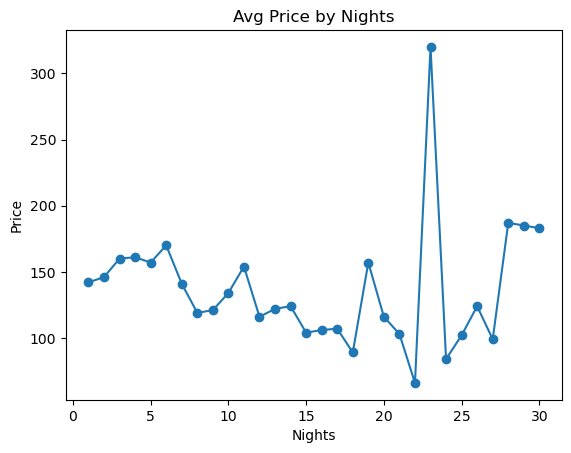

In [12]:
avg_price_by_nights = df.groupby('minimum_nights')['price'].mean().round()
avg_price_by_nights = avg_price_by_nights[avg_price_by_nights.index <= 30]
avg_price_by_nights
avg_price_by_nights.plot(kind= 'line',marker= 'o')
plt.title('Avg Price by Nights')
plt.ylabel('Price')
plt.xlabel('Nights')

10. Create a pie chart showing the proportion of room_type categories.

Text(0.5, 1.0, 'Proportion of Room Types')

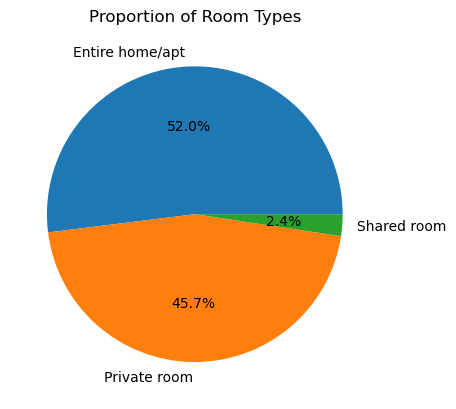

In [13]:
data = df['room_type'].value_counts()
plt.pie(x=data, labels=data.index, autopct='%1.1f%%')
plt.title('Proportion of Room Types')

11. Use a boxplot to compare price distribution across room_type (filter price < 500 first).

Text(0.5, 1.0, 'Price distribution across room type')

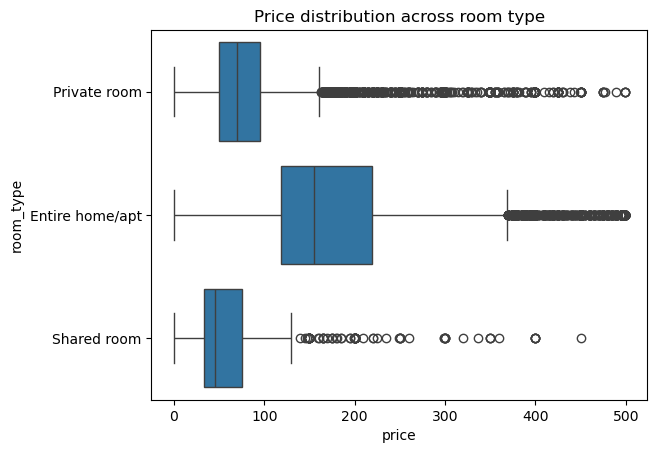

In [29]:
filtered_price = df[df['price'] < 500]
sns.boxplot(x= 'price',y='room_type',data= filtered_price)
plt.title('Price distribution across room type')

12. Use a violin plot to compare price across neighbourhood_group.

<Axes: xlabel='price', ylabel='neighbourhood_group'>

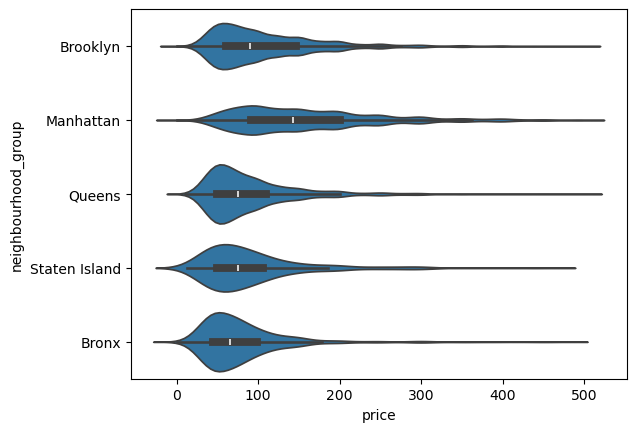

In [31]:
sns.violinplot(x = 'price',y= 'neighbourhood_group', data=filtered_price)

13. Create a scatter plot of latitude vs longitude, colored by neighbourhood_group — this recreates a rough map of NYC listings.

In [33]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Text(0, 0.5, 'Latitude')

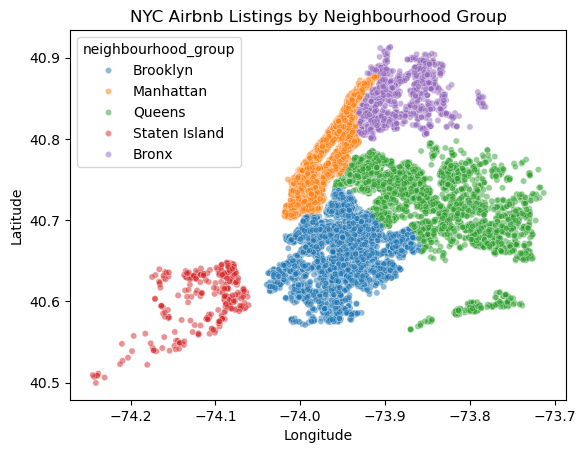

In [44]:
sns.scatterplot(x= 'longitude', y= 'latitude',hue='neighbourhood_group', data=df,s=20,alpha= 0.5)
plt.title('NYC Airbnb Listings by Neighbourhood Group')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

14. Create a scatter plot of latitude vs longitude, colored by price (filter outliers) to see where expensive listings cluster.

<Axes: xlabel='longitude', ylabel='latitude'>

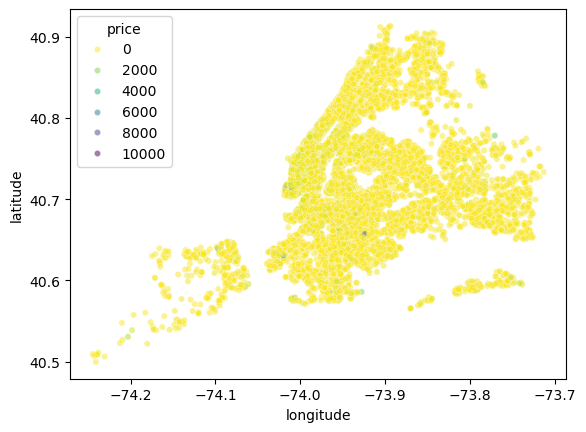

In [48]:
sns.scatterplot(x='longitude',y='latitude',hue='price',data=df,s=20,alpha=0.5,palette='viridis_r')

15. Use a countplot to show the number of listings per room_type, split further by neighbourhood_group.

<Figure size 1000x600 with 0 Axes>

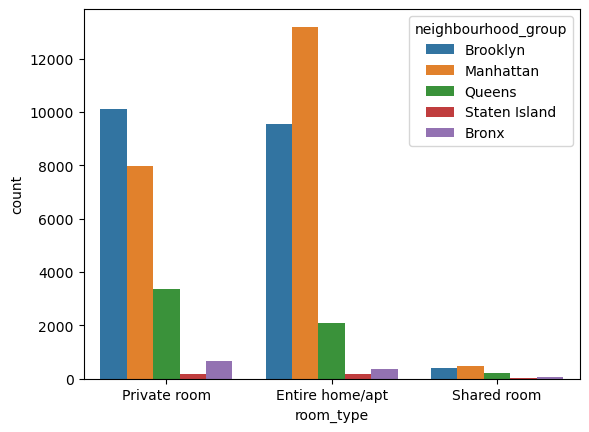

<Figure size 1000x600 with 0 Axes>

In [54]:
sns.countplot(x=df['room_type'],hue=df['neighbourhood_group'])
plt.figure(figsize=(10,6))

16. Use NumPy to calculate the mean, median, standard deviation, and 90th percentile of price.

In [65]:
mean = df['price'].mean()
median = df['price'].median()
std = df['price'].std()
percentile = np.percentile(df['price'],90)
print(mean)
print(median)
print(std)
print(percentile)

152.7206871868289
106.0
240.15416974718727
269.0


17. Use NumPy to flag outliers in price using the IQR method, then plot a boxplot before and after removing them.

In [77]:
#IQR method
q1 = np.percentile(df['price'],25)
q3 = np.percentile(df['price'],75)

IQR = q3-q1

#Outliers
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

outliers = df[((df['price'] < lower) | (df['price'] > upper))]
print(len(outliers))
cleaned = df[((df['price'] >= lower) & (df['price'] <= upper))]
print(len(cleaned))

2972
45923


18. Create a correlation heatmap of numeric columns (price, minimum_nights, number_of_reviews, reviews_per_month, calculated_host_listings_count, availability_365).

In [78]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<Axes: >

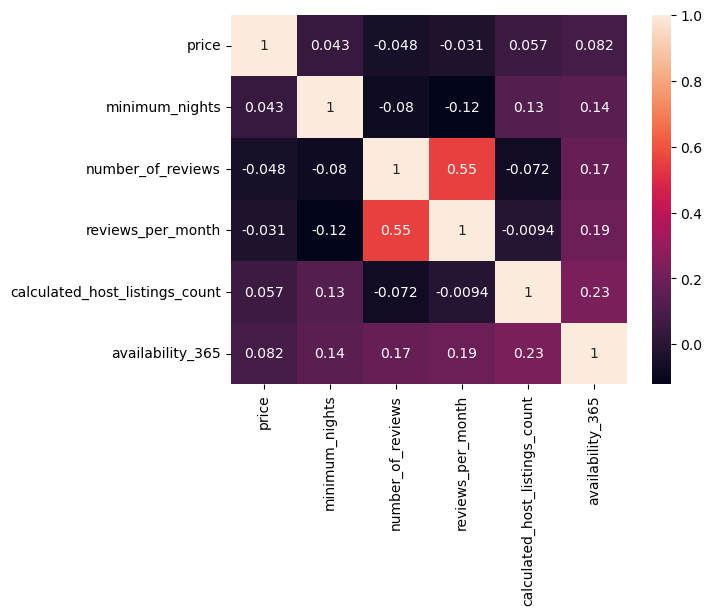

In [88]:
columnnnnn = df[['price','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']]
sns.heatmap(columnnnnn.corr(),annot=True)

19. Plot availability_365 distribution using a histogram — what does it tell you about how many listings are rarely available?

<Axes: xlabel='availability_365', ylabel='Count'>

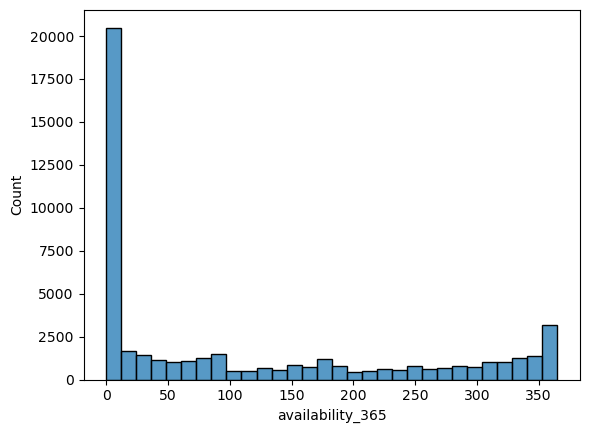

In [91]:
sns.histplot(x= df['availability_365'],bins=30)

In [97]:
(df['availability_365'] == 0).sum()

np.int64(17533)

20. Create a pairplot of price, number_of_reviews, minimum_nights, and availability_365 (filter price < 500 first) to spot any visual relationships.

In [104]:
filtered = df[(df['price'] < 500) & (df['minimum_nights'] <= 30)]

Text(0.5, 1.02, 'Pairwise Relationships (price < 500)')

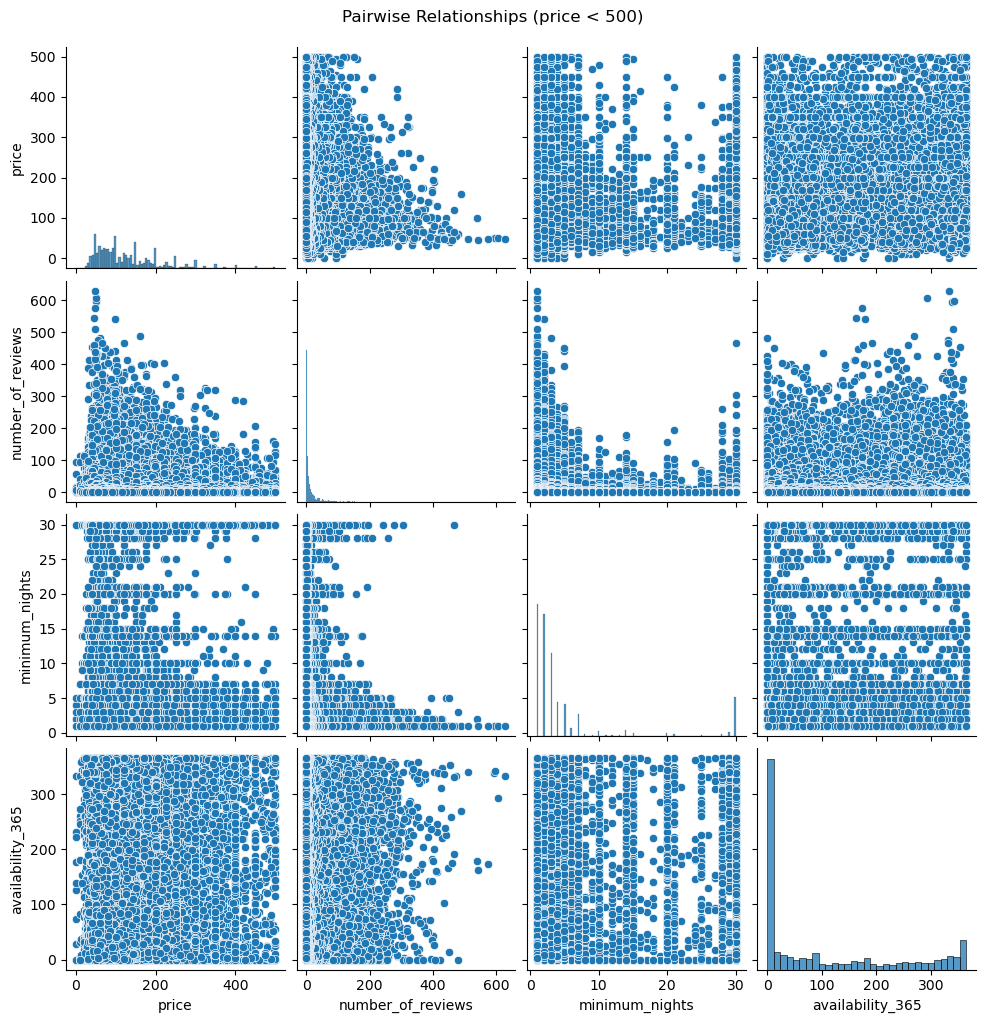

In [105]:
sns.pairplot(filtered[['price','number_of_reviews','minimum_nights','availability_365']])
plt.suptitle('Pairwise Relationships (price < 500)', y=1.02)